# Compare several versions of prompt in the Smart Farm use case

## Experiment setup

### Variants

The following list contains the identifiers of the variants (used in the names of the log files, separated by underscores) and their names (how they are presented in the paper):

* default = `jinja` (use Jinja prompt templates) + `sd2` (detailed domain description) + `retry1` (max-retries set to 1) + the LLM is given high-level instructions how to perform the ensemble assignment
* `p2` = swapped order of components and ensembles in the prompt
* `sd3` = reworded domain description

## Results

The generated raw results are saved in the [`/results/farm`](../results/farm) folder. However, when re-running this notebook, the newly generated results will be saved in the [`logs`](../logs) folder.
The plots for the paper are produced with the [`farm_plot.ipynb`](farm_plot.ipynb) notebook.

In [5]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [30]:
import subprocess
import os
import textwrap
import sys

env = os.environ.copy()
env["PYTHONPATH"] = env.get("PYTHONPATH", "") + os.pathsep + os.getcwd()
env["TF_CPP_MIN_LOG_LEVEL"] = "3"  # disable TF errors

def run(args, repeats=10, start=1):
    print(args)
    for repeat in range(repeats):
        print(f"  Run #{repeat + start}/{repeats + start - 1}")
        run = [sys.executable, "main.py", *args, "-s", str(repeat + start), "-e", str(repeat + start)]
        # if repeat % 10 == 0:
        #     run.append("--animation")
        # print(" ".join(run)); return

        result = subprocess.run(run, capture_output=True, env=env)
        stdout = result.stdout.decode("utf-8")
        stderr = result.stderr.decode("utf-8")

        damage = stdout.partition("damage: ")[2].partition("\n")[0]
        print(f"    Damage: {damage}")

        if stderr:
            stderr_lines = stderr.splitlines()
            stderr = '\n'.join(stderr_lines[-5:])
            print(f"    StdErr: {len(stderr_lines)} lines")
            print(textwrap.indent(stderr, "    "))

### Prepare configurations

In [33]:
grid_params = {
    "llm": ["configs/llm_gpt4omini.yaml", "configs/llm_o3mini.yaml"],
    "extra": [["farm/configs/simulation_description_2.yaml", "configs/jinja_prompt2.yaml"], "farm/configs/simulation_description_3.yaml"],
}

In [34]:
import itertools

grid = list(itertools.product(*grid_params.values()))
print(len(grid))

4


In [35]:
for i, params in enumerate(grid, start=1):
    print(f"{i}/{len(grid)}")

    args = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "configs/jinja.yaml", 
        "DSL/drones.yaml", "configs/retry1.yaml"]

    for param in params:
        if param is None:
            continue
        if isinstance(param, list):
            args.extend(param)
        else:
            args.append(param)

    args.append("farm/configs/no_battery_llm.yaml")

    for config_file in args:
        assert os.path.exists(config_file), f"File {config_file} does not exist"

    run(args, repeats=5, start=1)

1/4
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', 'farm/configs/simulation_description_2.yaml', 'configs/jinja_prompt2.yaml', 'farm/configs/no_battery_llm.yaml']
  Run #1/5
    Damage: 255
  Run #2/5
    Damage: 238
  Run #3/5
    Damage: 282
  Run #4/5
    Damage: 265
  Run #5/5
    Damage: 315
2/4
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', 'farm/configs/simulation_description_3.yaml', 'farm/configs/no_battery_llm.yaml']
  Run #1/5
    Damage: 284
  Run #2/5
    Damage: 169
  Run #3/5
    Damage: 250
  Run #4/5
    Damage: 296
  Run #5/5
    Damage: 254
3/4
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'configs/retry1.yaml', 'configs/llm_o3mini.yaml', 'farm/configs/simulation_description_2

## Results - Damage

In [74]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
sns.set(rc={'text.usetex' : True})
sns.set_theme()

In [2]:
allowed_params = ["jinja", "retry1", "sd2", "sd3", "p2"]
allowed_llms = ["gpt4omini", "o3mini"]

In [22]:
results_folder = Path("./results/farm")

In [32]:
results_files = sorted(results_folder.glob("*/*.csv"))
print(len(results_files), "files found")

152 files found


In [33]:
summary = pd.DataFrame(columns=["llm", "params", "name", "damage"])

In [34]:
for file in results_files:
    try:
        name = file.stem.split("-")[-1]
        parts = name.split("_")
        if not all(part in allowed_llms or part in allowed_params for part in parts):
            continue

        llm = next(part for part in parts if part in allowed_llms)
        params = []
        for param in allowed_params[2:]:
            if param in name:
                params.append(param)
        if params == []:
            params = ["Default"]
        params = ",\n".join(params)

        data = pd.read_csv(file)
        damage = data.iloc[299]["damage"]  # 300th step

        summary.loc[len(summary)] = [llm, params, file.stem, damage]
    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

summary.to_csv(results_folder / "summary_prompt.csv", index=False)

In [35]:
summary = pd.read_csv(results_folder / "summary_prompt.csv")
summary

,llm,params,name,damage
0,gpt4omini,"sd2,\np2",001-2026-04-16-15-38-02-jinja_retry1_gpt4omini...,255
1,gpt4omini,"sd2,\np2",002-2026-04-16-15-41-43-jinja_retry1_gpt4omini...,238
2,gpt4omini,"sd2,\np2",003-2026-04-16-15-45-00-jinja_retry1_gpt4omini...,282
3,gpt4omini,"sd2,\np2",004-2026-04-16-15-48-14-jinja_retry1_gpt4omini...,265
4,gpt4omini,"sd2,\np2",005-2026-04-16-15-51-29-jinja_retry1_gpt4omini...,315
5,gpt4omini,sd3,001-2026-04-16-15-54-55-jinja_retry1_gpt4omini...,284
6,gpt4omini,sd3,002-2026-04-16-15-57-56-jinja_retry1_gpt4omini...,169
7,gpt4omini,sd3,003-2026-04-16-16-01-43-jinja_retry1_gpt4omini...,250
8,gpt4omini,sd3,004-2026-04-16-16-05-53-jinja_retry1_gpt4omini...,296
9,gpt4omini,sd3,005-2026-04-16-16-09-40-jinja_retry1_gpt4omini...,254


In [36]:
palette = {
    "gpt4omini": "tab:red",
    "o3mini": "tab:blue",
}

In [37]:
llm_names = {
    "gpt4omini": "GPT-4o mini",
    "o3mini": "OpenAI o3-mini",
}
summary['LLM'] = summary['llm'].map(llm_names)
palette_LLM = {v: palette[k] for k, v in llm_names.items()}

In [58]:
params_names = {
    "sd2": "Default\n(Zero strategy)",
    "sd2,\np2": "Different\nprompt order",
    "sd3": "Different\ndomain\ndescription"
}
summary['Params'] = summary['params'].map(params_names)

In [56]:
summary["damage_rate"] = summary["damage"] / 754

In [47]:
summary

,llm,params,name,damage,LLM,Params
0,gpt4omini,"sd2,\np2",001-2026-04-16-15-38-02-jinja_retry1_gpt4omini...,255,GPT-4o mini,Different prompt order
1,gpt4omini,"sd2,\np2",002-2026-04-16-15-41-43-jinja_retry1_gpt4omini...,238,GPT-4o mini,Different prompt order
2,gpt4omini,"sd2,\np2",003-2026-04-16-15-45-00-jinja_retry1_gpt4omini...,282,GPT-4o mini,Different prompt order
3,gpt4omini,"sd2,\np2",004-2026-04-16-15-48-14-jinja_retry1_gpt4omini...,265,GPT-4o mini,Different prompt order
4,gpt4omini,"sd2,\np2",005-2026-04-16-15-51-29-jinja_retry1_gpt4omini...,315,GPT-4o mini,Different prompt order
5,gpt4omini,sd3,001-2026-04-16-15-54-55-jinja_retry1_gpt4omini...,284,GPT-4o mini,Different domain description
6,gpt4omini,sd3,002-2026-04-16-15-57-56-jinja_retry1_gpt4omini...,169,GPT-4o mini,Different domain description
7,gpt4omini,sd3,003-2026-04-16-16-01-43-jinja_retry1_gpt4omini...,250,GPT-4o mini,Different domain description
8,gpt4omini,sd3,004-2026-04-16-16-05-53-jinja_retry1_gpt4omini...,296,GPT-4o mini,Different domain description
9,gpt4omini,sd3,005-2026-04-16-16-09-40-jinja_retry1_gpt4omini...,254,GPT-4o mini,Different domain description


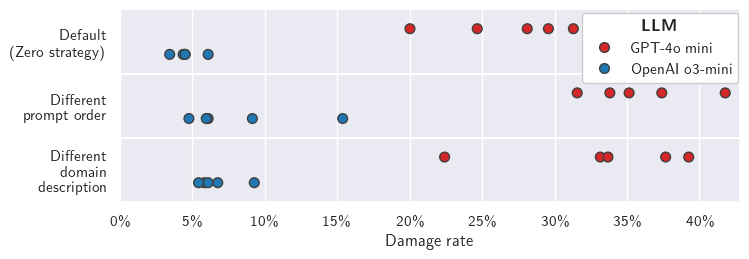

In [82]:
fig, ax = plt.subplots(figsize=(8, 2.5))
plot_kwargs = {
    "dodge": True,
    "jitter": False,
    "size": 7,
    "linewidth": 1,
}
order = params_names.values()

ax_llm = sns.stripplot(x="damage_rate", y="Params", hue="LLM", data=summary, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys(), order=order, **plot_kwargs)
ax_llm.legend(facecolor='white', loc="upper right", title="\\textbf{LLM}", bbox_to_anchor=(0.01, 0.02, 1, 1), framealpha=1)
# # add custom jitter
# for dots in ax_llm.collections:
#     xs, ys = dots.get_offsets().T
#     print(xs)
#     jitter_ys = ys[:]
#     for i, x in enumerate(xs):
#         count = np.sum(np.isclose(xs[:i], x, atol=0.01, rtol=0))
#         jitter_ys[i] = ys[i] + 0.01 * count
#     dots.set_offsets(np.column_stack((xs, jitter_ys)))

# add lines separating params
for y in range(0, len(order) - 1):
  plt.plot([0, summary['damage_rate'].max() + 0.01], [y + 0.5, y + 0.5], c='white')

plt.xlim(0, summary['damage_rate'].max() + 0.01)
plt.ylim(2.5, -0.5)
plt.ylabel("")
plt.xlabel("Damage rate")
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.savefig(results_folder / "damage_prompt_strip.pdf", bbox_inches="tight")
plt.show()